# Inferencia Bayesiana de la gravedad: MCMC y ABC

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/blob/main/APBF/teorico_practicos/Semana06_mcmc_abc.ipynb)

En esta notebook vamos a estimar la aceleración de la gravedad $g$ a partir de mediciones de tiempos de caída libre. El objetivo no es solamente obtener un número, sino describir la **incertidumbre** sobre ese número usando dos enfoques bayesianos:

- **MCMC** con Metropolis-Hastings, cuando podemos escribir la verosimilitud.
- **ABC** por rechazo, cuando preferimos trabajar sólo con un simulador y una distancia entre datos.

In [1]:
import matplotlib.pyplot as plt
import torch

SEED = 42
torch.manual_seed(SEED)

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

## El problema físico

Para una caída libre desde una altura $h$, sin rozamiento y partiendo del reposo, el tiempo ideal de caída es

$$
t(h; g) = \sqrt{\frac{2h}{g}}.
$$

En un experimento real no observamos exactamente ese valor ideal. Vamos a modelar cada medición como

$$
t_i^{\mathrm{obs}} = \sqrt{\frac{2h_i}{g}} + \epsilon_i, \qquad
\epsilon_i \sim \mathcal N(0, \sigma_t^2).
$$

Nuestro parámetro desconocido es $g$. Como información previa usaremos un prior uniforme amplio:

$$
g \sim \mathrm{Uniforme}(5, 15) \; \mathrm{m/s^2}.
$$

Como los datos de esta notebook son sintéticos, conocemos el valor usado para generarlos: $g_{\mathrm{real}}=9.81\,\mathrm{m/s^2}$. En un experimento real ese valor no estaría disponible.

In [2]:
g_real = 9.81
sigma_t = 0.02
alturas = torch.tensor([0.5, 1.0, 1.5, 2.0, 2.5])


def tiempos_ideales(g, h):
    return torch.sqrt(2.0 * h / g)


def simular_experimento(g, alturas, sigma_t):
    t_ideal = tiempos_ideales(g, alturas)
    ruido = sigma_t * torch.randn_like(alturas)
    return t_ideal + ruido


t_obs = simular_experimento(g_real, alturas, sigma_t)

print("Alturas (m):", alturas)
print("Tiempos observados (s):", t_obs)

Alturas (m): tensor([0.5000, 1.0000, 1.5000, 2.0000, 2.5000])
Tiempos observados (s): tensor([0.3260, 0.4541, 0.5577, 0.6432, 0.6915])


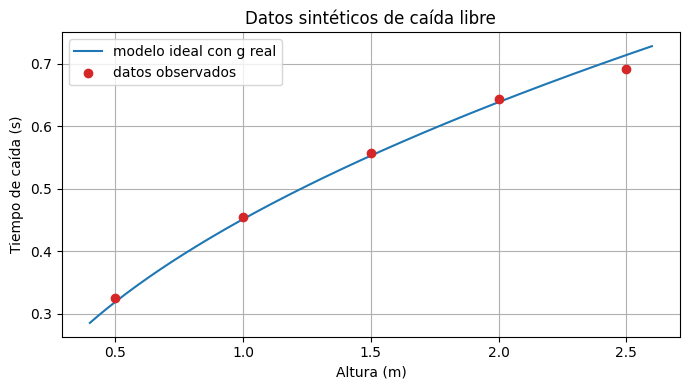

In [3]:
h_grid = torch.linspace(0.4, 2.6, 200)

plt.plot(h_grid, tiempos_ideales(torch.tensor(g_real), h_grid), label="modelo ideal con g real")
plt.scatter(alturas, t_obs, color="tab:red", zorder=3, label="datos observados")
plt.xlabel("Altura (m)")
plt.ylabel("Tiempo de caída (s)")
plt.title("Datos sintéticos de caída libre")
plt.legend()
plt.tight_layout()
plt.show()

## Posterior bayesiana

La regla de Bayes nos dice que

$$
p(g \mid t^{\mathrm{obs}}) \propto p(t^{\mathrm{obs}} \mid g)\,p(g).
$$

En este problema sí conocemos la verosimilitud, porque asumimos ruido gaussiano independiente en cada medición:

$$
p(t^{\mathrm{obs}} \mid g) = \prod_i \mathcal N\left(t_i^{\mathrm{obs}}\mid \sqrt{\frac{2h_i}{g}}, \sigma_t^2\right).
$$

Trabajaremos con log-probabilidades porque son más estables numéricamente. Para tener una referencia visual, también calculamos la posterior en una grilla fina de valores de $g$.

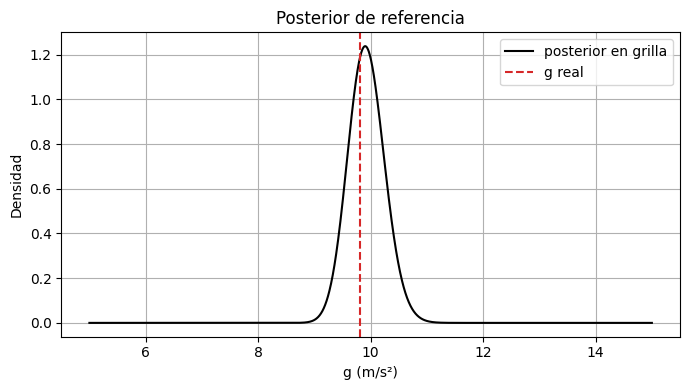

In [4]:
prior_low = 5.0
prior_high = 15.0


def log_prior(g):
    if prior_low <= g <= prior_high:
        return torch.tensor(0.0)
    return torch.tensor(-float("inf"))


def log_likelihood(g):
    t_pred = tiempos_ideales(g, alturas)
    residuos = t_obs - t_pred
    return -0.5 * torch.sum((residuos / sigma_t) ** 2)


def log_posterior(g):
    return log_prior(g) + log_likelihood(g)


def log_posterior_grid(g_values):
    t_pred = torch.sqrt(2.0 * alturas.unsqueeze(0) / g_values.unsqueeze(1))
    residuos = t_obs.unsqueeze(0) - t_pred
    log_like = -0.5 * torch.sum((residuos / sigma_t) ** 2, dim=1)
    log_prior_values = torch.where(
        (g_values >= prior_low) & (g_values <= prior_high),
        torch.zeros_like(g_values),
        torch.full_like(g_values, -float("inf")),
    )
    return log_prior_values + log_like


g_grid = torch.linspace(prior_low, prior_high, 2000)
logp_grid = log_posterior_grid(g_grid)
posterior_grid = torch.exp(logp_grid - torch.max(logp_grid))
posterior_grid = posterior_grid / torch.trapz(posterior_grid, g_grid)

plt.plot(g_grid, posterior_grid, color="black", label="posterior en grilla")
plt.axvline(g_real, linestyle="--", color="tab:red", label="g real")
plt.xlabel("g (m/s²)")
plt.ylabel("Densidad")
plt.title("Posterior de referencia")
plt.legend()
plt.tight_layout()
plt.show()

---

## Enfoque 1: MCMC con Metropolis-Hastings

MCMC construye una cadena de valores de $g$ cuya distribución estacionaria es la posterior. En Metropolis-Hastings repetimos estos pasos:

1. Partimos de un valor actual $g$.
2. Proponemos un nuevo valor cercano: $g' = g + \eta$, con $\eta$ aleatorio.
3. Comparamos la posterior en $g'$ contra la posterior en $g$.
4. Aceptamos siempre si la propuesta mejora la posterior; si no, la aceptamos con cierta probabilidad.

La cadena no produce muestras independientes, pero después de descartar un período inicial de **burn-in**, sus valores se pueden usar para resumir la incertidumbre posterior.

In [5]:
def metropolis_hastings(n_steps, proposal_width, g_inicial):
    samples = torch.zeros(n_steps)
    g_actual = torch.tensor(float(g_inicial))
    logp_actual = log_posterior(g_actual)
    aceptados = 0

    for i in range(n_steps):
        g_propuesta = g_actual + proposal_width * torch.randn(())
        logp_propuesta = log_posterior(g_propuesta)
        log_alpha = logp_propuesta - logp_actual

        if torch.log(torch.rand(())) < log_alpha:
            g_actual = g_propuesta
            logp_actual = logp_propuesta
            aceptados += 1

        samples[i] = g_actual

    return samples, aceptados / n_steps


n_steps = 20_000
proposal_width = 0.15
burn_in = 3_000

samples_mcmc, tasa_aceptacion_mcmc = metropolis_hastings(
    n_steps=n_steps,
    proposal_width=proposal_width,
    g_inicial=10.0,
)
g_posterior_mcmc = samples_mcmc[burn_in:]

print(f"Cantidad de pasos MCMC: {n_steps}")
print(f"Burn-in descartado: {burn_in}")
print(f"Tasa de aceptación: {tasa_aceptacion_mcmc:.4f}")
print(f"Media posterior MCMC: {g_posterior_mcmc.mean().item():.3f} m/s²")
print(f"Desvío estándar posterior MCMC: {g_posterior_mcmc.std().item():.3f} m/s²")

Cantidad de pasos MCMC: 20000
Burn-in descartado: 3000
Tasa de aceptación: 0.8530
Media posterior MCMC: 9.946 m/s²
Desvío estándar posterior MCMC: 0.326 m/s²


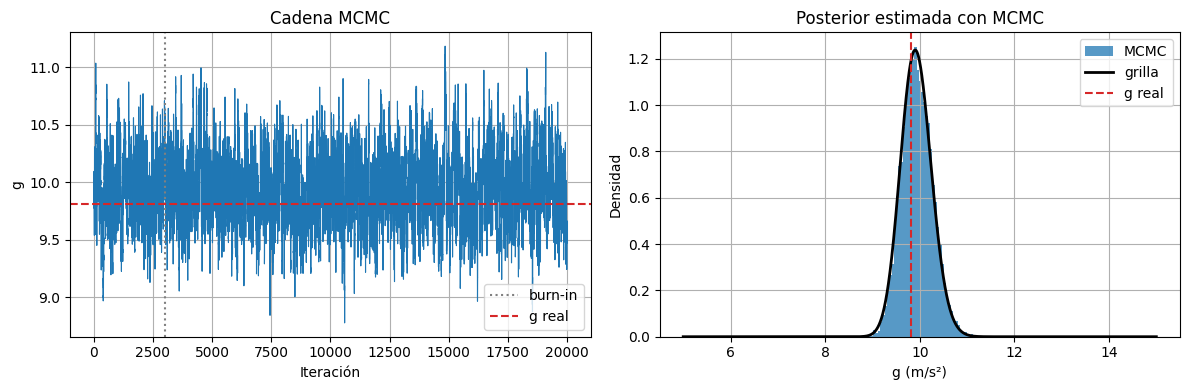

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(samples_mcmc, linewidth=0.8)
axes[0].axvline(burn_in, linestyle=":", color="gray", label="burn-in")
axes[0].axhline(g_real, linestyle="--", color="tab:red", label="g real")
axes[0].set_xlabel("Iteración")
axes[0].set_ylabel("g")
axes[0].set_title("Cadena MCMC")
axes[0].legend()

axes[1].hist(g_posterior_mcmc, bins=50, density=True, alpha=0.75, label="MCMC")
axes[1].plot(g_grid, posterior_grid, color="black", linewidth=2, label="grilla")
axes[1].axvline(g_real, linestyle="--", color="tab:red", label="g real")
axes[1].set_xlabel("g (m/s²)")
axes[1].set_ylabel("Densidad")
axes[1].set_title("Posterior estimada con MCMC")
axes[1].legend()

plt.tight_layout()
plt.show()

### Comentarios sobre MCMC

En este ejemplo MCMC aprovecha toda la información de la verosimilitud gaussiana. La tolerancia al ruido no se elige a mano: está codificada por $\sigma_t$ en el modelo probabilístico.

Sus ventajas principales son:

- aproxima la posterior correcta si la cadena está bien mezclada;
- usa la forma completa de la verosimilitud;
- permite calcular medias, intervalos de credibilidad y otros resúmenes de incertidumbre.

Sus costos son:

- requiere poder evaluar $p(t^{\mathrm{obs}}\mid g)$, aunque sea hasta una constante;
- las muestras están correlacionadas;
- hay que elegir y diagnosticar la propuesta, el burn-in y la mezcla de la cadena.

---

## Enfoque 2: ABC por rechazo

ABC significa **Approximate Bayesian Computation**. La idea central es evitar escribir la verosimilitud. En su lugar usamos el simulador:

1. Muestreamos un valor $g$ del prior.
2. Simulamos un experimento completo con ese $g$.
3. Comparamos la simulación con los datos observados usando una distancia.
4. Aceptamos $g$ si la distancia es menor que una tolerancia $\epsilon$.

En esta notebook usamos como distancia la norma euclídea entre el vector de tiempos simulados y el vector observado:

$$
d(t^{\mathrm{sim}}, t^{\mathrm{obs}})=\|t^{\mathrm{sim}}-t^{\mathrm{obs}}\|_2.
$$

Cuanto más chico sea $\epsilon$, más exigente es la aceptación y más cerca estaremos de la posterior exacta. Pero si $\epsilon$ es demasiado chico, casi no aceptamos muestras.

In [17]:
def sample_prior(n):
    return prior_low + (prior_high - prior_low) * torch.rand(n)


def simular_experimentos_batch(g_values, alturas, sigma_t):
    t_ideal = torch.sqrt(2.0 * alturas.unsqueeze(0) / g_values.unsqueeze(1))
    ruido = sigma_t * torch.randn_like(t_ideal)
    return t_ideal + ruido


def distancia(t_sim, t_obs):
    return torch.norm(t_sim - t_obs.unsqueeze(0), p=2, dim=1)


def abc_rechazo(n_propuestas, epsilon):
    g_propuestos = sample_prior(n_propuestas)
    t_sim = simular_experimentos_batch(g_propuestos, alturas, sigma_t)
    distancias = distancia(t_sim, t_obs)
    aceptadas = distancias < epsilon
    return g_propuestos, distancias, g_propuestos[aceptadas]


n_propuestas = 500_000
epsilon = 0.02

g_propuestos, distancias_abc, g_aceptados_abc = abc_rechazo(n_propuestas, epsilon)

print(f"Cantidad de propuestas ABC: {n_propuestas}")
print(f"Tolerancia epsilon: {epsilon}")
print(f"Cantidad de aceptadas: {len(g_aceptados_abc)}")
print(f"Tasa de aceptación: {len(g_aceptados_abc) / n_propuestas:.4f}")

if len(g_aceptados_abc) > 0:
    print(f"Media posterior ABC: {g_aceptados_abc.mean().item():.3f} m/s²")
    print(f"Desvío estándar posterior ABC: {g_aceptados_abc.std().item():.3f} m/s²")

Cantidad de propuestas ABC: 500000
Tolerancia epsilon: 0.02
Cantidad de aceptadas: 870
Tasa de aceptación: 0.0017
Media posterior ABC: 9.940 m/s²
Desvío estándar posterior ABC: 0.347 m/s²


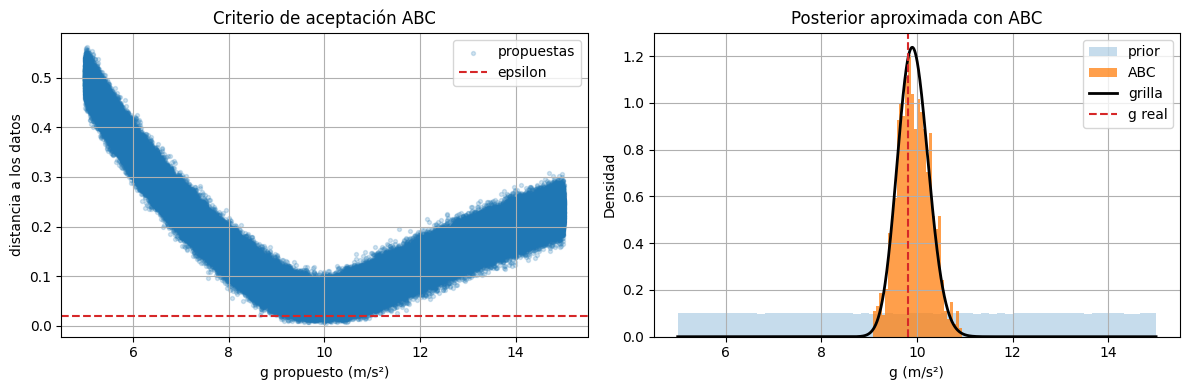

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(g_propuestos, distancias_abc, s=8, alpha=0.2, label="propuestas")
axes[0].axhline(epsilon, linestyle="--", color="tab:red", label="epsilon")
axes[0].set_xlabel("g propuesto (m/s²)")
axes[0].set_ylabel("distancia a los datos")
axes[0].set_title("Criterio de aceptación ABC")
axes[0].legend()

axes[1].hist(g_propuestos, bins=60, density=True, alpha=0.25, label="prior")
if len(g_aceptados_abc) > 0:
    axes[1].hist(g_aceptados_abc, bins=30, density=True, alpha=0.75, label="ABC")
axes[1].plot(g_grid, posterior_grid, color="black", linewidth=2, label="grilla")
axes[1].axvline(g_real, linestyle="--", color="tab:red", label="g real")
axes[1].set_xlabel("g (m/s²)")
axes[1].set_ylabel("Densidad")
axes[1].set_title("Posterior aproximada con ABC")
axes[1].legend()

plt.tight_layout()
plt.show()

### Comentarios sobre ABC

ABC es especialmente útil cuando tenemos un buen simulador pero la verosimilitud es difícil, costosa o directamente imposible de escribir. En ese caso, comparar simulaciones contra observaciones puede ser mucho más natural.

Sus ventajas principales son:

- no exige evaluar una verosimilitud explícita;
- se adapta bien a modelos generativos complejos;
- es muy intuitivo para conectar simulación, datos y parámetros.

Sus costos son:

- la posterior es aproximada y depende de $\epsilon$;
- elegir buenas estadísticas resumen y buenas distancias puede ser delicado;
- ABC por rechazo suele desperdiciar muchas simulaciones, sobre todo en problemas de mayor dimensión.

In [19]:
def intervalo_credibilidad(samples, nivel=0.90):
    alpha = (1.0 - nivel) / 2.0
    return torch.quantile(samples, torch.tensor([alpha, 1.0 - alpha]))


def imprimir_resumen(nombre, samples):
    intervalo = intervalo_credibilidad(samples)
    print(f"{nombre}")
    print(f"  media: {samples.mean().item():.3f} m/s²")
    print(f"  desvío: {samples.std().item():.3f} m/s²")
    print(f"  intervalo 90%: [{intervalo[0].item():.3f}, {intervalo[1].item():.3f}] m/s²")


imprimir_resumen("MCMC", g_posterior_mcmc)
if len(g_aceptados_abc) > 0:
    imprimir_resumen("ABC", g_aceptados_abc)
print(f"Valor usado para simular los datos: {g_real:.3f} m/s²")

MCMC
  media: 9.946 m/s²
  desvío: 0.326 m/s²
  intervalo 90%: [9.435, 10.495] m/s²
ABC
  media: 9.940 m/s²
  desvío: 0.347 m/s²
  intervalo 90%: [9.407, 10.500] m/s²
Valor usado para simular los datos: 9.810 m/s²


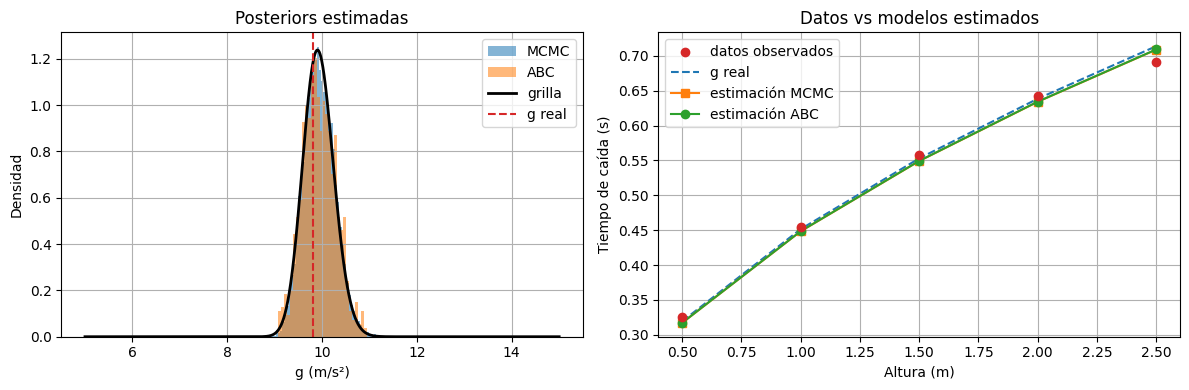

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(g_posterior_mcmc, bins=50, density=True, alpha=0.55, label="MCMC")
if len(g_aceptados_abc) > 0:
    axes[0].hist(g_aceptados_abc, bins=30, density=True, alpha=0.55, label="ABC")
axes[0].plot(g_grid, posterior_grid, color="black", linewidth=2, label="grilla")
axes[0].axvline(g_real, linestyle="--", color="tab:red", label="g real")
axes[0].set_xlabel("g (m/s²)")
axes[0].set_ylabel("Densidad")
axes[0].set_title("Posteriors estimadas")
axes[0].legend()

if len(g_aceptados_abc) > 0:
    g_est_abc = g_aceptados_abc.mean()
else:
    g_est_abc = torch.tensor(float("nan"))
g_est_mcmc = g_posterior_mcmc.mean()

axes[1].scatter(alturas, t_obs, color="tab:red", zorder=3, label="datos observados")
axes[1].plot(alturas, tiempos_ideales(torch.tensor(g_real), alturas), "--", label="g real")
axes[1].plot(alturas, tiempos_ideales(g_est_mcmc, alturas), "-s", label="estimación MCMC")
if len(g_aceptados_abc) > 0:
    axes[1].plot(alturas, tiempos_ideales(g_est_abc, alturas), "-o", label="estimación ABC")
axes[1].set_xlabel("Altura (m)")
axes[1].set_ylabel("Tiempo de caída (s)")
axes[1].set_title("Datos vs modelos estimados")
axes[1].legend()

plt.tight_layout()
plt.show()